In [1]:
import urllib.request
import os

# 1. 將類別與想要存放的資料夾名稱綁定成一個字典
dataset_groups = {
    "Group_A": ['airplane', 'apple', 'dog', 't-shirt', 'star'],  # 差異大
    "Group_B": ['clock', 'compass', 'wheel', 'donut', 'pizza']   # 差異小
}

base_url = 'https://storage.googleapis.com/quickdraw_dataset/full/numpy_bitmap/'

print("📥 開始自動分類下載 QuickDraw 資料集...")

# 2. 針對每一組進行迴圈處理
for folder_name, categories in dataset_groups.items():
    # os.makedirs 可以建立資料夾，exist_ok=True 代表如果資料夾已經存在就不會報錯
    os.makedirs(folder_name, exist_ok=True)
    print(f"\n📁 進入資料夾: {folder_name}/")
    
    for category in categories:
        url = base_url + category.replace('_', '%20') + '.npy'
        
        # os.path.join 會自動幫你組合路徑，例如 "Group_A/dog.npy"
        file_path = os.path.join(folder_name, f"{category}.npy")
        
        if not os.path.exists(file_path):
            print(f"  -- 正在下載 {category}...")
            urllib.request.urlretrieve(url, file_path)
            print(f"  ✅ {category} 下載完成！")
        else:
            print(f"  ⏩ {category} 已經存在，跳過。")

print("\n🎉 所有資料皆已分類下載完畢！")

📥 開始自動分類下載 QuickDraw 資料集...

📁 進入資料夾: Group_A/
  ⏩ airplane 已經存在，跳過。
  ⏩ apple 已經存在，跳過。
  ⏩ dog 已經存在，跳過。
  ⏩ t-shirt 已經存在，跳過。
  ⏩ star 已經存在，跳過。

📁 進入資料夾: Group_B/
  ⏩ clock 已經存在，跳過。
  ⏩ compass 已經存在，跳過。
  ⏩ wheel 已經存在，跳過。
  ⏩ donut 已經存在，跳過。
  ⏩ pizza 已經存在，跳過。

🎉 所有資料皆已分類下載完畢！


In [2]:
# import sys
# !{sys.executable} -m pip install scikit-learn numpy matplotlib

In [3]:
import sklearn
import numpy as np
import matplotlib.pyplot as plt
print("環境完美運作，沒有任何 DLL 錯誤！")

環境完美運作，沒有任何 DLL 錯誤！


In [4]:
import numpy as np
import os
from sklearn.model_selection import train_test_split

def load_and_preprocess_data(categories, folder_name, max_per_class=1000):
    X_list, y_list = [], []
    print(f"🔍 開始從 {folder_name}/ 載入並處理資料...")
    
    for label_id, category in enumerate(categories):
        # 組合出正確的檔案路徑，例如 "Group_A/airplane.npy"
        file_path = os.path.join(folder_name, f"{category}.npy")
        
        # 檢查檔案是否存在，避免報錯
        if os.path.exists(file_path):
            data = np.load(file_path)[:max_per_class]
            X_list.append(data)
            y_list.append(np.full(len(data), label_id))
        else:
            print(f"⚠️ 找不到檔案: {file_path}，請確認下載步驟是否完成。")
            
    # 將所有類別合併
    X = np.concatenate(X_list, axis=0)
    y = np.concatenate(y_list, axis=0)
    
    # 影像正規化 (0~255 轉換為 0~1)，這對神經網路收斂極度重要
    X = X.astype('float32') / 255.0
    
    # 切分訓練集 (80%) 與測試集 (20%)，並使用 stratify 保持類別平衡
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )
    
    print(f"✅ {folder_name} 處理完成！訓練集形狀: {X_train.shape}, 測試集形狀: {X_test.shape}\n")
    return X_train, X_test, y_train, y_test

# 1. 定義我們的兩組挑戰名單
GROUP_A = ['airplane', 'apple', 'dog', 't-shirt', 'star']
GROUP_B = ['clock', 'compass', 'wheel', 'donut', 'pizza']

# 2. 執行讀取函數
X_train_A, X_test_A, y_train_A, y_test_A = load_and_preprocess_data(GROUP_A, "Group_A")
X_train_B, X_test_B, y_train_B, y_test_B = load_and_preprocess_data(GROUP_B, "Group_B")

🔍 開始從 Group_A/ 載入並處理資料...
✅ Group_A 處理完成！訓練集形狀: (4000, 784), 測試集形狀: (1000, 784)

🔍 開始從 Group_B/ 載入並處理資料...
✅ Group_B 處理完成！訓練集形狀: (4000, 784), 測試集形狀: (1000, 784)



🚀 開始進行 Group A vs Group B 的模型大亂鬥！(神經網路需要較多時間，請耐心等候)

========== 正在測試 Group A (差異度大) ==========
[Logistic Regression (線性)] 準確度: 0.7420 | 耗時: 13.10 秒
[Random Forest (樹狀)] 準確度: 0.8570 | 耗時: 1.89 秒
[Neural Network (神經網路)] 準確度: 0.8520 | 耗時: 1.68 秒
-------------------------------------------------------
========== 正在測試 Group B (差異度小) ==========
[Logistic Regression (線性)] 準確度: 0.5620 | 耗時: 4.34 秒
[Random Forest (樹狀)] 準確度: 0.7120 | 耗時: 2.34 秒
[Neural Network (神經網路)] 準確度: 0.6970 | 耗時: 1.05 秒
-------------------------------------------------------


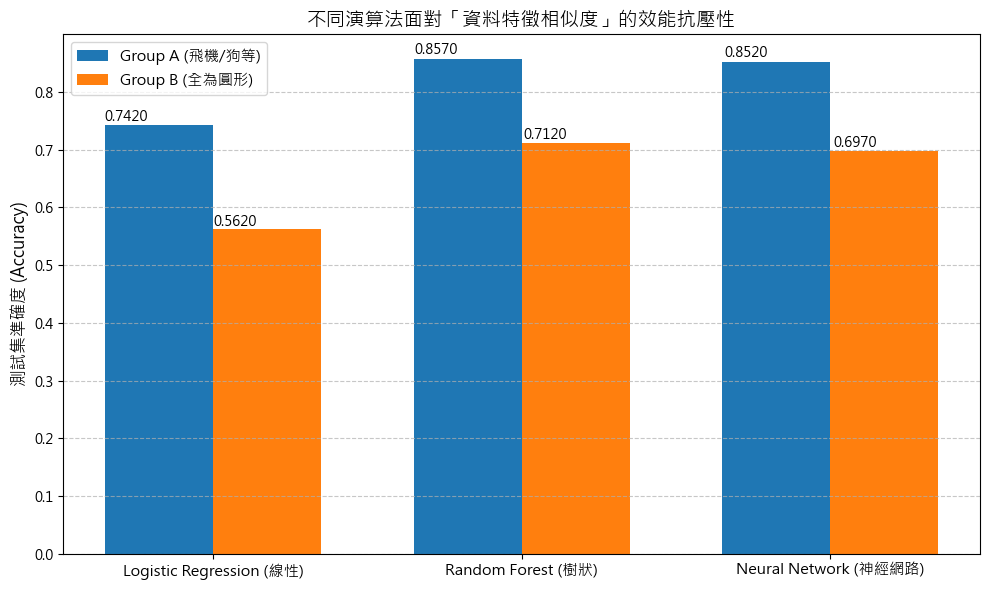

In [5]:
import time
import numpy as np
import matplotlib.pyplot as plt
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier

# 1. 打包兩組資料以利迴圈處理 (名稱已統一)
datasets = {
    "Group A (差異度大)": (X_train_A, X_test_A, y_train_A, y_test_A),
    "Group B (差異度小)": (X_train_B, X_test_B, y_train_B, y_test_B)
}

# 2. 準備三種不同原理的模型
models = {
    "Logistic Regression (線性)": LogisticRegression(max_iter=500, C=1.0),
    "Random Forest (樹狀)": RandomForestClassifier(n_estimators=100, random_state=42),
    "Neural Network (神經網路)": MLPClassifier(
        hidden_layer_sizes=(128, 64), 
        activation='relu', 
        solver='adam', 
        max_iter=500, 
        early_stopping=True, 
        random_state=42
    )
}

# 準備紀錄準確度的字典 (名稱已統一)
results = {"Group A (差異度大)": [], "Group B (差異度小)": []}
model_names = list(models.keys())

print("🚀 開始進行 Group A vs Group B 的模型大亂鬥！(神經網路需要較多時間，請耐心等候)\n")

# 3. 執行實驗迴圈
for group_name, (X_train, X_test, y_train, y_test) in datasets.items():
    print(f"========== 正在測試 {group_name} ==========")
    for model_name, model in models.items():
        # Neural Network 與 Logistic Regression 極度依賴特徵標準化
        pipeline = Pipeline([
            ('scaler', StandardScaler()),
            ('clf', model)
        ])
        
        start_time = time.time()
        pipeline.fit(X_train, y_train)
        train_time = time.time() - start_time
        
        acc = pipeline.score(X_test, y_test)
        results[group_name].append(acc)
        
        print(f"[{model_name}] 準確度: {acc:.4f} | 耗時: {train_time:.2f} 秒")
    print("-" * 55)

# 4. 繪製對比圖表
# 設定中文字體避免亂碼
plt.rcParams['font.sans-serif'] = ['Arial Unicode MS', 'Microsoft JhengHei', 'SimHei']
plt.rcParams['axes.unicode_minus'] = False

x = np.arange(len(model_names))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
rects1 = ax.bar(x - width/2, results["Group A (差異度大)"], width, label='Group A (飛機/狗等)')
rects2 = ax.bar(x + width/2, results["Group B (差異度小)"], width, label='Group B (全為圓形)')

ax.set_ylabel('測試集準確度 (Accuracy)', fontsize=12)
ax.set_title('不同演算法面對「資料特徵相似度」的效能抗壓性', fontsize=14)
ax.set_xticks(x)
ax.set_xticklabels(model_names, fontsize=11)
ax.legend(fontsize=11)
ax.grid(axis='y', linestyle='--', alpha=0.7)

# 在長條圖上標示準確度數字
for p in ax.patches:
    ax.annotate(f"{p.get_height():.4f}", (p.get_x() * 1.005, p.get_height() * 1.01))

plt.tight_layout()
plt.show()

🧠 正在重新訓練神經網路以分析 Group B (圓形系列)... 請稍候。


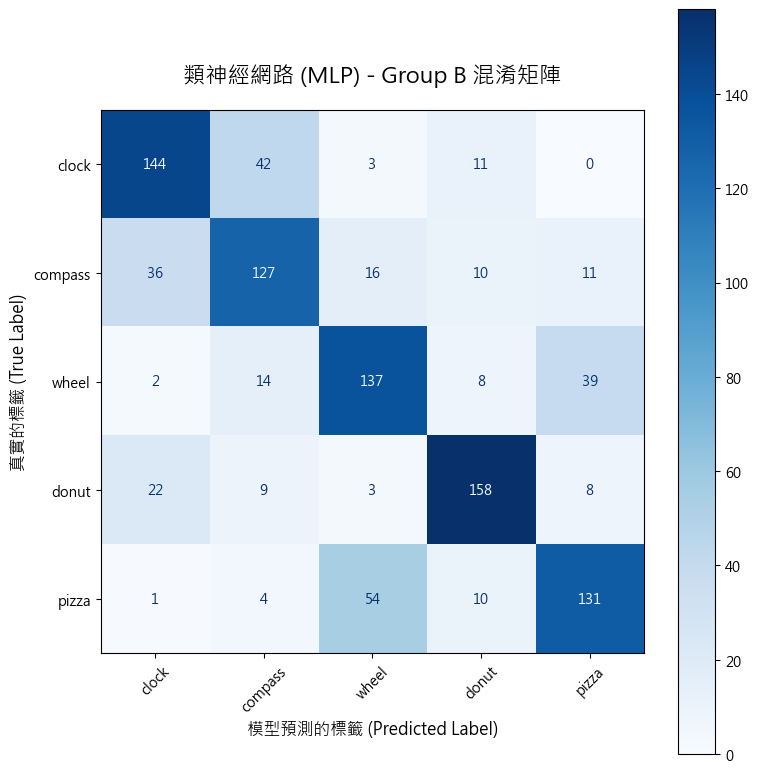

In [6]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier

# 1. 單獨抓出我們想深入分析的模型 (MLP) 與資料集 (Group B)
print("🧠 正在重新訓練神經網路以分析 Group B (圓形系列)... 請稍候。")
mlp_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('mlp', MLPClassifier(
        hidden_layer_sizes=(128, 64), 
        activation='relu', 
        solver='adam', 
        max_iter=500, 
        early_stopping=True, 
        random_state=42
    ))
])

# 進行訓練
mlp_pipeline.fit(X_train_B, y_train_B)

# 2. 讓模型進行預測，交出答卷
y_pred_B = mlp_pipeline.predict(X_test_B)

# 3. 計算並繪製混淆矩陣
cm = confusion_matrix(y_test_B, y_pred_B)

# 設定中文字體避免亂碼
plt.rcParams['font.sans-serif'] = ['Arial Unicode MS', 'Microsoft JhengHei', 'SimHei']
plt.rcParams['axes.unicode_minus'] = False

# 畫圖設定
fig, ax = plt.subplots(figsize=(8, 8))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=GROUP_B)

# cmap='Blues' 代表用藍色漸層顯示，數值越大顏色越深
disp.plot(cmap='Blues', ax=ax, values_format='d', xticks_rotation=45)

plt.title('類神經網路 (MLP) - Group B 混淆矩陣', fontsize=16, pad=20)
plt.xlabel('模型預測的標籤 (Predicted Label)', fontsize=12)
plt.ylabel('真實的標籤 (True Label)', fontsize=12)

plt.tight_layout()
plt.show()

🚀 開始測試不同資料量對模型的影響...

========== 處理 Group A (差異大) ==========
資料量  500 筆完成測試。
資料量 1500 筆完成測試。
資料量 2500 筆完成測試。
資料量 4000 筆完成測試。
----------------------------------------
========== 處理 Group B (差異小) ==========
資料量  500 筆完成測試。
資料量 1500 筆完成測試。
資料量 2500 筆完成測試。
資料量 4000 筆完成測試。
----------------------------------------


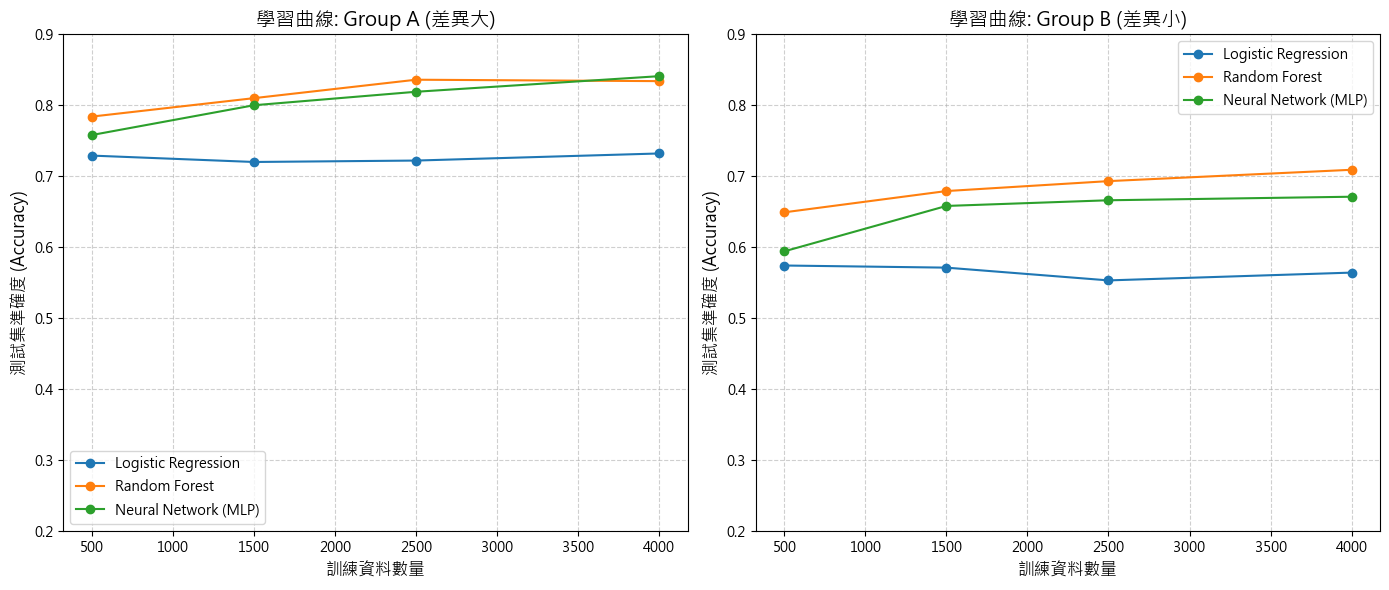

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.utils import resample
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier

# 1. 準備模型與資料集
models = {
    "Logistic Regression": LogisticRegression(max_iter=500, C=1.0),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "Neural Network (MLP)": MLPClassifier(hidden_layer_sizes=(128, 64), activation='relu', solver='adam', max_iter=500, early_stopping=True, random_state=42)
}

datasets = {
    "Group A (差異大)": (X_train_A, X_test_A, y_train_A, y_test_A),
    "Group B (差異小)": (X_train_B, X_test_B, y_train_B, y_test_B)
}

# 2. 定義要測試的訓練資料量級距
# 假設完整訓練集有 4000 筆，我們測試 4 個階段
train_sizes = [500, 1500, 2500, len(X_train_A)]

# 準備記錄結果的結構
learning_curve_results = {group: {model: [] for model in models} for group in datasets}

print("🚀 開始測試不同資料量對模型的影響...\n")

# 3. 執行實驗
for group_name, (X_train, X_test, y_train, y_test) in datasets.items():
    print(f"========== 處理 {group_name} ==========")
    
    for size in train_sizes:
        # 使用 resample 進行分層抽樣，確保考卷範圍與比例正確
        X_sub, y_sub = resample(X_train, y_train, n_samples=size, random_state=42, stratify=y_train)
        
        for model_name, model in models.items():
            pipeline = Pipeline([('scaler', StandardScaler()), ('clf', model)])
            pipeline.fit(X_sub, y_sub)
            acc = pipeline.score(X_test, y_test)  # 永遠用同一份 X_test 評估
            learning_curve_results[group_name][model_name].append(acc)
            
        print(f"資料量 {size:4d} 筆完成測試。")
    print("-" * 40)

# 4. 將結果視覺化為折線圖
plt.rcParams['font.sans-serif'] = ['Arial Unicode MS', 'Microsoft JhengHei', 'SimHei']
plt.rcParams['axes.unicode_minus'] = False

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
axes = {"Group A (差異大)": ax1, "Group B (差異小)": ax2}

for group_name, ax in axes.items():
    for model_name in models.keys():
        ax.plot(train_sizes, learning_curve_results[group_name][model_name], marker='o', label=model_name)
    
    ax.set_title(f"學習曲線: {group_name}", fontsize=14)
    ax.set_xlabel("訓練資料數量", fontsize=12)
    ax.set_ylabel("測試集準確度 (Accuracy)", fontsize=12)
    ax.set_ylim([0.2, 0.9])  # 固定 Y 軸範圍以便左右圖公平比較
    ax.legend(fontsize=10)
    ax.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

在測試集中，神經網路總共猜錯了 303 張圖。
以下隨機展示其中 9 張被 AI 搞混的塗鴉：



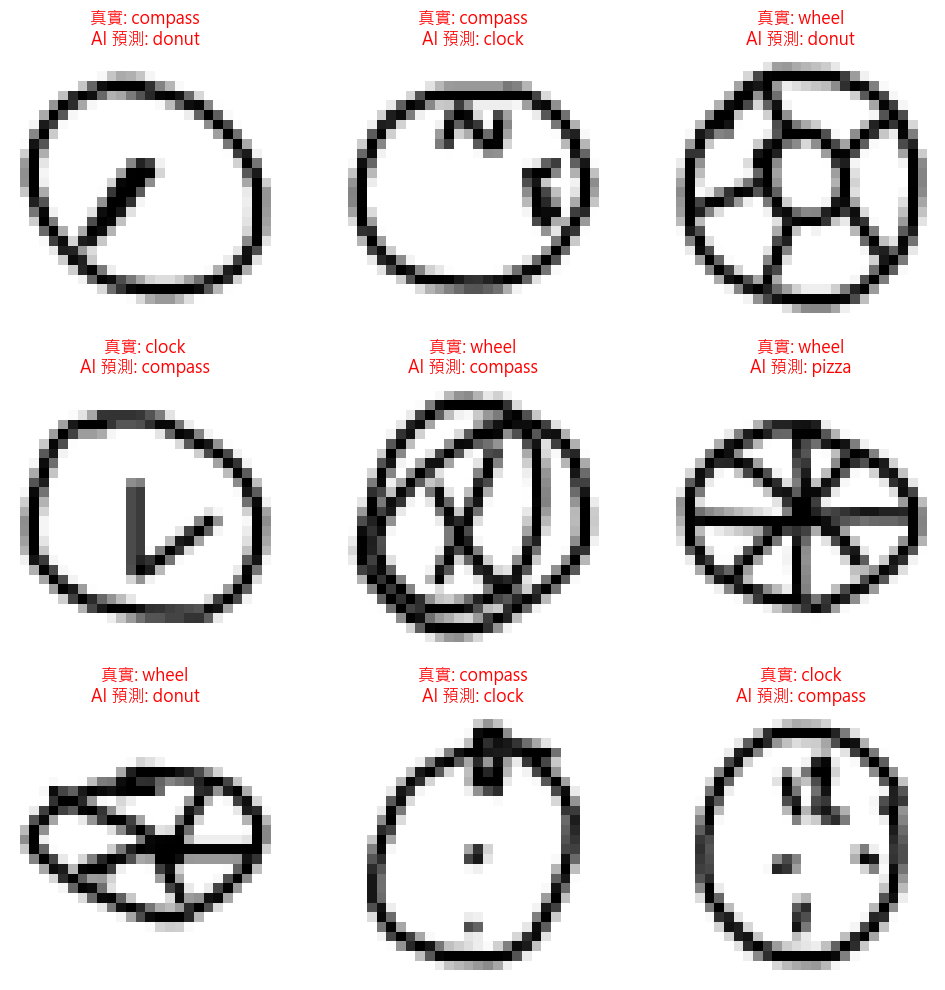

In [8]:
import numpy as np
import matplotlib.pyplot as plt

# 找出預測錯誤的圖片索引
# 確保你前面已經跑過 mlp_pipeline.predict(X_test_B) 產生了 y_pred_B
misclassified_idx = np.where(y_test_B != y_pred_B)[0]

print(f"在測試集中，神經網路總共猜錯了 {len(misclassified_idx)} 張圖。")
print("以下隨機展示其中 9 張被 AI 搞混的塗鴉：\n")

# 設定畫布
plt.figure(figsize=(10, 10))
plt.rcParams['font.sans-serif'] = ['Arial Unicode MS', 'Microsoft JhengHei', 'SimHei']

# 隨機挑選 9 張錯誤圖片來展示
np.random.seed(42) # 固定亂數，讓每次抽出來的錯誤圖片一樣
sample_indices = np.random.choice(misclassified_idx, 9, replace=False)

for i, idx in enumerate(sample_indices):
    plt.subplot(3, 3, i + 1)
    
    # 將攤平的 784 維陣列，還原回 28x28 的圖片
    img = X_test_B[idx].reshape(28, 28)
    
    # 畫出圖片 (反轉顏色讓背景變白、筆觸變黑，比較好看)
    plt.imshow(255 - (img * 255), cmap='gray')
    
    # 標示出「真實答案」與「AI的預測」
    true_label = GROUP_B[y_test_B[idx]]
    pred_label = GROUP_B[y_pred_B[idx]]
    
    # 如果預測錯誤，標題用紅色顯示
    plt.title(f"真實: {true_label}\nAI 預測: {pred_label}", color='red', fontsize=12)
    plt.axis('off')

plt.tight_layout()
plt.show()

In [9]:
# 1. 安裝並匯入 joblib 套件
import joblib

# 2. 儲存模型 (將剛剛訓練好的 MLP 存檔)
# 這樣你的專案資料夾會多出一個 'best_mlp_model.joblib' 的檔案
joblib.dump(mlp_pipeline, 'best_mlp_model.joblib')
print("✅ 模型已成功儲存至硬碟！")

# --- 假設這是明天，你重新打開了電腦 ---

# 3. 瞬間載入模型，不需要重新訓練！
loaded_model = joblib.load('best_mlp_model.joblib')

# 直接拿來考試
acc = loaded_model.score(X_test_B, y_test_B)
print(f"載入的模型準確度為: {acc:.4f}")

✅ 模型已成功儲存至硬碟！
載入的模型準確度為: 0.6970


In [1]:
from sklearn.metrics import classification_report

# 封裝一個通用函數
def evaluate_any_model(model_name, model_instance, X_train, y_train, X_test, y_test, class_names):
    print(f"啟動訓練: {model_name}...")
    
    # 自動綁定標準化
    pipe = Pipeline([('scaler', StandardScaler()), ('clf', model_instance)])
    
    # 訓練與計時
    start = time.time()
    pipe.fit(X_train, y_train)
    cost_time = time.time() - start
    
    # 預測
    y_pred = pipe.predict(X_test)
    acc = pipe.score(X_test, y_test)
    
    print(f"✅ {model_name} 訓練完成! 耗時 {cost_time:.2f} 秒 | 準確度: {acc:.4f}")
    
    # 印出進階的分類報告 (包含精確率 Precision 與召回率 Recall)
    print(classification_report(y_test, y_pred, target_names=class_names))
    print("="*50)
    
    return pipe # 回傳訓練好的模型

# 未來你想測試新模型，只要寫這樣一行就好了！超級乾淨！
# from sklearn.svm import SVC
# svm_model = evaluate_any_model("Support Vector Machine", SVC(), X_train_B, y_train_B, X_test_B, y_test_B, GROUP_B)

In [11]:
# 請在全新的 Cell 貼上這段程式碼並執行
# (前提是你要先執行過定義 evaluate_any_model 的那個 Cell 喔！)

from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

print("🌟 啟動模組化測試：快速引入全新演算法挑戰 Group B (圓形系列)\n")

# 測試 1: SVM (支持向量機) - 尋找最佳決策邊界的高手
svm_model = evaluate_any_model(
    model_name="SVM (支持向量機)", 
    model_instance=SVC(kernel='rbf', random_state=42), 
    X_train=X_train_B, y_train=y_train_B, 
    X_test=X_test_B, y_test=y_test_B, 
    class_names=GROUP_B
)

# 測試 2: KNN (K-近鄰) - 靠「物以類聚」來投票的演算法
knn_model = evaluate_any_model(
    model_name="KNN (K-近鄰, K=5)", 
    model_instance=KNeighborsClassifier(n_neighbors=10), 
    X_train=X_train_B, y_train=y_train_B, 
    X_test=X_test_B, y_test=y_test_B, 
    class_names=GROUP_B
)

🌟 啟動模組化測試：快速引入全新演算法挑戰 Group B (圓形系列)

啟動訓練: SVM (支持向量機)...
✅ SVM (支持向量機) 訓練完成! 耗時 5.34 秒 | 準確度: 0.7290
              precision    recall  f1-score   support

       clock       0.75      0.81      0.78       200
     compass       0.73      0.61      0.67       200
       wheel       0.66      0.68      0.67       200
       donut       0.80      0.82      0.81       200
       pizza       0.70      0.71      0.71       200

    accuracy                           0.73      1000
   macro avg       0.73      0.73      0.73      1000
weighted avg       0.73      0.73      0.73      1000

啟動訓練: KNN (K-近鄰, K=5)...
✅ KNN (K-近鄰, K=5) 訓練完成! 耗時 0.03 秒 | 準確度: 0.4850
              precision    recall  f1-score   support

       clock       0.39      0.90      0.55       200
     compass       0.37      0.24      0.29       200
       wheel       0.48      0.28      0.36       200
       donut       0.61      0.55      0.58       200
       pizza       0.81      0.46      0.58       200

    accur

In [12]:
# 請在全新的 Cell 貼上這段程式碼並執行
import joblib

print("🧠 正在從硬碟喚醒之前儲存的神經網路模型...")

# 1. 直接讀取存檔 (請確保你上一階段有執行過 joblib.dump)
try:
    loaded_mlp = joblib.load('best_mlp_model.joblib')
    print("✅ 模型喚醒成功！完全不需要重新 fit (訓練)！\n")
    
    # 2. 直接拿來考試
    acc = loaded_mlp.score(X_test_B, y_test_B)
    print(f"📊 喚醒後的模型，在 Group B 測試集的準確度依然是: {acc:.4f}")
    
except FileNotFoundError:
    print("⚠️ 找不到存檔！請確認你剛才有沒有執行 `joblib.dump(mlp_pipeline, 'best_mlp_model.joblib')` 喔！")

🧠 正在從硬碟喚醒之前儲存的神經網路模型...
✅ 模型喚醒成功！完全不需要重新 fit (訓練)！

📊 喚醒後的模型，在 Group B 測試集的準確度依然是: 0.6970


In [13]:
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsClassifier

print("🌟 啟動 KNN 拯救計畫！\n")

# --- 拯救方案 1: 調整超參數 (K值與距離權重) ---
# 把 K 稍微放大，並加上 weights='distance' (距離越近的鄰居，投票權重越高)
improved_knn = KNeighborsClassifier(n_neighbors=9, weights='distance')

evaluate_any_model(
    model_name="微調版 KNN (K=9, 考慮距離權重)", 
    model_instance=improved_knn, 
    X_train=X_train_B, y_train=y_train_B, 
    X_test=X_test_B, y_test=y_test_B, 
    class_names=GROUP_B
)

# --- 拯救方案 2: 降維打擊 (PCA + KNN) ---
# 建立一個微型管線：先用 PCA 把 784 維壓縮到 50 維，再做 KNN
# (注意：你的超級函數裡面已經有 StandardScaler 了，所以實際流程會是：標準化 -> PCA -> KNN)
pca_knn_pipeline = Pipeline([
    ('pca', PCA(n_components=50, random_state=42)),
    ('knn', KNeighborsClassifier(n_neighbors=9, weights='distance'))
])

evaluate_any_model(
    model_name="終極版 KNN (PCA 降維至 50 維 + K=9)", 
    model_instance=pca_knn_pipeline, 
    X_train=X_train_B, y_train=y_train_B, 
    X_test=X_test_B, y_test=y_test_B, 
    class_names=GROUP_B
)

🌟 啟動 KNN 拯救計畫！

啟動訓練: 微調版 KNN (K=9, 考慮距離權重)...
✅ 微調版 KNN (K=9, 考慮距離權重) 訓練完成! 耗時 0.04 秒 | 準確度: 0.5150
              precision    recall  f1-score   support

       clock       0.43      0.87      0.58       200
     compass       0.44      0.30      0.36       200
       wheel       0.50      0.28      0.36       200
       donut       0.58      0.61      0.60       200
       pizza       0.76      0.50      0.60       200

    accuracy                           0.52      1000
   macro avg       0.54      0.52      0.50      1000
weighted avg       0.54      0.52      0.50      1000

啟動訓練: 終極版 KNN (PCA 降維至 50 維 + K=9)...
✅ 終極版 KNN (PCA 降維至 50 維 + K=9) 訓練完成! 耗時 0.15 秒 | 準確度: 0.6100
              precision    recall  f1-score   support

       clock       0.58      0.80      0.67       200
     compass       0.62      0.37      0.46       200
       wheel       0.56      0.52      0.54       200
       donut       0.64      0.69      0.66       200
       pizza       0.66      0.68      0

UnicodeDecodeError: 'cp950' codec can't decode byte 0xe2 in position 2950: illegal multibyte sequence

UnicodeDecodeError: 'cp950' codec can't decode byte 0xe2 in position 2950: illegal multibyte sequence

Pipeline(steps=[('scaler', StandardScaler()),
                ('clf',
                 Pipeline(steps=[('pca', PCA(n_components=50, random_state=42)),
                                 ('knn',
                                  KNeighborsClassifier(n_neighbors=9,
                                                       weights='distance'))]))])

In [14]:
from sklearn import set_config

# 將模型顯示方式強制改為傳統純文字，避開 HTML 渲染
set_config(display="text")

print("✅ 已成功切換為純文字顯示模式，不會再報 cp950 錯誤了！")

✅ 已成功切換為純文字顯示模式，不會再報 cp950 錯誤了！


🌟 啟動 K-Means 非監督式學習！(不給標準答案，讓 AI 自己摸索)

🔍 AI 正在盲目地尋找資料中的相似特徵...
✅ 分群完成！耗時: 0.29 秒



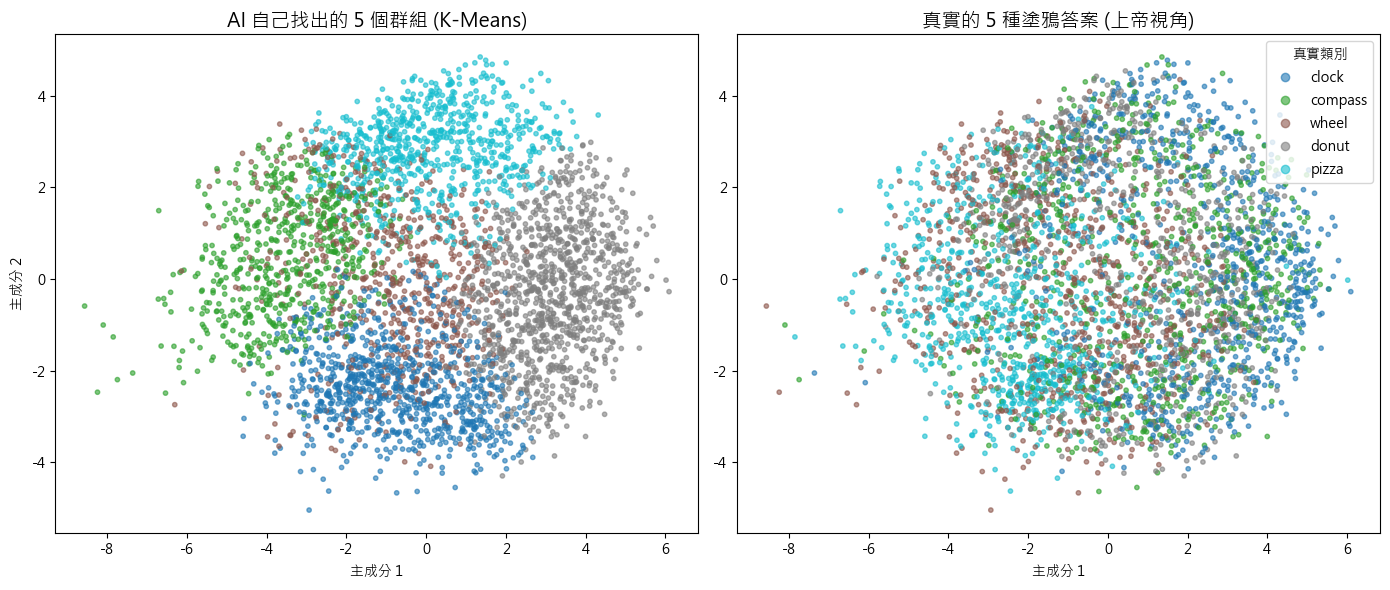

In [15]:
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np
import time

print("🌟 啟動 K-Means 非監督式學習！(不給標準答案，讓 AI 自己摸索)\n")

# 1. 建立 K-Means 模型
# 我們偷偷知道資料有 5 種 (時鐘、指南針、輪子、甜甜圈、披薩)，所以請它找 5 群 (n_clusters=5)
kmeans_model = KMeans(n_clusters=5, random_state=42, n_init=10)

# 2. 訓練模型 (注意看！這裡只有 X_train_B，沒有 y_train_B！)
start_time = time.time()
# 為了加快速度與去除雜訊，我們先用 PCA 降維到 50 維再分群
pca = PCA(n_components=50, random_state=42)
X_train_pca = pca.fit_transform(X_train_B)

print("🔍 AI 正在盲目地尋找資料中的相似特徵...")
kmeans_model.fit(X_train_pca)
print(f"✅ 分群完成！耗時: {time.time() - start_time:.2f} 秒\n")

# 3. 取得 AI 自己分出來的標籤 (0, 1, 2, 3, 4)
# 注意：這些數字不代表真實的類別，只是 AI 說「這是第 0 群、這是第 1 群...」
ai_clusters = kmeans_model.labels_

# 4. 視覺化大招：把 784 維降到「2 維」畫在平面上，看看 AI 分得好不好！
pca_2d = PCA(n_components=2, random_state=42)
X_2d = pca_2d.fit_transform(X_train_B)

plt.figure(figsize=(14, 6))
plt.rcParams['font.sans-serif'] = ['Arial Unicode MS', 'Microsoft JhengHei', 'SimHei']

# 左圖：AI 盲分出來的群組
plt.subplot(1, 2, 1)
scatter1 = plt.scatter(X_2d[:, 0], X_2d[:, 1], c=ai_clusters, cmap='tab10', alpha=0.6, s=10)
plt.title("AI 自己找出的 5 個群組 (K-Means)", fontsize=14)
plt.xlabel("主成分 1")
plt.ylabel("主成分 2")

# 右圖：上帝視角的真實答案
plt.subplot(1, 2, 2)
scatter2 = plt.scatter(X_2d[:, 0], X_2d[:, 1], c=y_train_B, cmap='tab10', alpha=0.6, s=10)
plt.title("真實的 5 種塗鴉答案 (上帝視角)", fontsize=14)
plt.xlabel("主成分 1")

# 添加圖例
legend1 = plt.legend(*scatter2.legend_elements(), title="真實類別", loc="upper right")
for i, text in enumerate(legend1.get_texts()):
    text.set_text(GROUP_B[i])

plt.tight_layout()
plt.show()

In [16]:
from sklearn.model_selection import GridSearchCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
import time

print("🔍 啟動 GridSearchCV：讓電腦自動尋找 KNN 的最佳超參數！\n")

# 1. 建立基礎管線
knn_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('knn', KNeighborsClassifier())
])

# 2. 定義「超參數網格 (Grid)」
# 我們讓電腦自己去測試 K=3, 5, 7, 9, 11，而且同時測試兩種距離權重 (uniform, distance)
param_grid = {
    'knn__n_neighbors': [3, 5, 7, 9, 11, 15],
    'knn__weights': ['uniform', 'distance']
}

# 3. 設定網格搜索 (cv=5 代表進行 5-Fold 交叉驗證，確保分數不是靠運氣)
grid_search = GridSearchCV(knn_pipe, param_grid, cv=5, n_jobs=-1, verbose=1)

# 4. 開始暴力搜索 (這會訓練 6 * 2 * 5 = 60 次模型！)
start_time = time.time()
grid_search.fit(X_train_B, y_train_B)
cost_time = time.time() - start_time

print(f"\n✅ 搜索完成！總耗時: {cost_time:.2f} 秒")
print("-" * 50)
print(f"🏆 電腦找到的最佳參數組合是: {grid_search.best_params_}")
print(f"📈 該組合在交叉驗證中的最高準確度: {grid_search.best_score_:.4f}")

# 用最好的模型直接去考期末考 (測試集)
best_model = grid_search.best_estimator_
test_acc = best_model.score(X_test_B, y_test_B)
print(f"🎯 使用最佳模型在未見過的測試集上，最終準確度為: {test_acc:.4f}")

🔍 啟動 GridSearchCV：讓電腦自動尋找 KNN 的最佳超參數！

Fitting 5 folds for each of 12 candidates, totalling 60 fits

✅ 搜索完成！總耗時: 5.61 秒
--------------------------------------------------
🏆 電腦找到的最佳參數組合是: {'knn__n_neighbors': 7, 'knn__weights': 'distance'}
📈 該組合在交叉驗證中的最高準確度: 0.5105
🎯 使用最佳模型在未見過的測試集上，最終準確度為: 0.5130


In [24]:
import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
import numpy as np

print("🧠 啟動 CNN 特徵萃取 + K-Means 分群接力賽！\n")

# 1. 恢復 2D 空間：把 784 維的一維陣列，折疊回 28x28 的二維圖片！
# (這是 CNN 能看懂形狀的關鍵)
X_train_cnn = X_train_B.reshape(-1, 28, 28, 1)

# 2. 打造一個輕量級的 CNN 神經網路
model = models.Sequential([
    # 第一層：找邊緣 (32個特徵濾鏡)
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)),
    layers.MaxPooling2D((2, 2)),
    # 第二層：找形狀 (64個特徵濾鏡)
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    # 攤平準備萃取精華
    layers.Flatten(),
    # 🌟 關鍵層：這 64 個神經元就是我們要的「語意特徵 (Embedding)」
    layers.Dense(64, activation='relu', name='feature_layer'),
    # 輸出層：5 個塗鴉類別
    layers.Dense(5, activation='softmax')
])

model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# 3. 訓練 CNN (教它認圖)
print("正在訓練 CNN... (請稍等約 10-20 秒)")
model.fit(X_train_cnn, y_train_B, epochs=5, batch_size=32, verbose=1)

# 4. 斷尾求生！把 CNN 最後的分類器砍掉，只保留到 'feature_layer'
feature_extractor = tf.keras.Model(
    inputs=model.inputs, 
    outputs=model.get_layer('feature_layer').output
)

# 5. 用斷尾的 CNN 把圖片翻譯成 64 維的高階特徵！
print("\n🔄 正在將圖片轉換為 64 維度的高階語意特徵...")
cnn_features = feature_extractor.predict(X_train_cnn)

# 6. 把這些聰明的特徵交給 K-Means 去分群！
print("📊 將高階特徵交給 K-Means 進行 5 群分類...")
kmeans_cnn = KMeans(n_clusters=5, random_state=42, n_init=10)
cnn_clusters = kmeans_cnn.fit_predict(cnn_features)

# 7. 視覺化：看看 CNN + K-Means 有沒有成功切開那些圓形塗鴉！
pca_2d = PCA(n_components=2, random_state=42)
cnn_features_2d = pca_2d.fit_transform(cnn_features)

plt.figure(figsize=(8, 6))
plt.rcParams['font.sans-serif'] = ['Arial Unicode MS', 'Microsoft JhengHei', 'SimHei']
scatter = plt.scatter(cnn_features_2d[:, 0], cnn_features_2d[:, 1], c=y_train_B, cmap='tab10', alpha=0.7, s=15)
plt.title("CNN 萃取特徵後的 K-Means 分群空間", fontsize=14)
plt.xlabel("CNN 特徵主成分 1")
plt.ylabel("CNN 特徵主成分 2")

legend = plt.legend(*scatter.legend_elements(), title="真實類別", loc="upper right")
for i, text in enumerate(legend.get_texts()):
    text.set_text(GROUP_B[i])

plt.tight_layout()
plt.show()

ModuleNotFoundError: No module named 'tensorflow'

In [20]:
%pip install tensorflow

Note: you may need to restart the kernel to use updated packages.


ERROR: Could not find a version that satisfies the requirement tensorflow (from versions: none)

[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip
ERROR: No matching distribution found for tensorflow
